# Tunnetilan tunnistus kuvista FER-2013-datasetillä

Tämä notebook kokoaa projektin keskeiset vaiheet yhteen näkymään. Se käyttää valmiita `src/`-moduuleja, mutta datan tarkistus, koulutus ja arviointi voidaan ajaa suoraan tästä notebookista:

1. datasetin rakenteen tarkistus
2. baseline-CNN:n koulutus
3. siirto-oppimismallin koulutus
4. mallien arviointi ja tulosten tallennus

Notebook toimii projektin pääasiallisena työskentely- ja dokumentointipohjana.

## Käyttöohje

Varmista ennen ajoa:

- riippuvuudet on asennettu komennolla `pip install -r ../requirements.txt`
- datasetti on kansiossa `../dataset/raw/train`, `../dataset/raw/val` ja `../dataset/raw/test`
- notebook ajetaan tästä projektista käsin

In [1]:
from pathlib import Path
import sys
import json

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "dataset" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "report"
MODELS_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Models dir:", MODELS_DIR)
print("Report dir:", REPORT_DIR)

Project root: D:\Oma aihe\Tunnetilan tunnistus kuvista
Data dir: D:\Oma aihe\Tunnetilan tunnistus kuvista\dataset\raw
Models dir: D:\Oma aihe\Tunnetilan tunnistus kuvista\models
Report dir: D:\Oma aihe\Tunnetilan tunnistus kuvista\report


In [2]:
from data_pipeline import create_datasets
from models import build_model

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix


## Datasetin tarkistus

In [3]:
for split in ["train", "val", "test"]:
    split_path = DATA_DIR / split
    print(f"[{split}]")
    for class_dir in sorted([p for p in split_path.iterdir() if p.is_dir()]):
        count = len(list(class_dir.glob("*.jpg"))) + len(list(class_dir.glob("*.png"))) + len(list(class_dir.glob("*.jpeg")))
        print(f"  {class_dir.name}: {count}")

[train]
  angry: 3396
  disgust: 371
  fear: 3483
  happy: 6133
  neutral: 4221
  sad: 4106
  surprise: 2696
[val]
  angry: 599
  disgust: 65
  fear: 614
  happy: 1082
  neutral: 744
  sad: 724
  surprise: 475
[test]
  angry: 958
  disgust: 111
  fear: 1024
  happy: 1774
  neutral: 1233
  sad: 1247
  surprise: 831


## Datasetit TensorFlow'lle

In [4]:
IMAGE_SIZE = 96
BATCH_SIZE = 32

train_ds, val_ds, test_ds, class_names = create_datasets(
    data_dir=str(DATA_DIR),
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    augment=True,
)

class_names

Found 24406 files belonging to 7 classes.
Found 4303 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

## Esimerkkikuvia

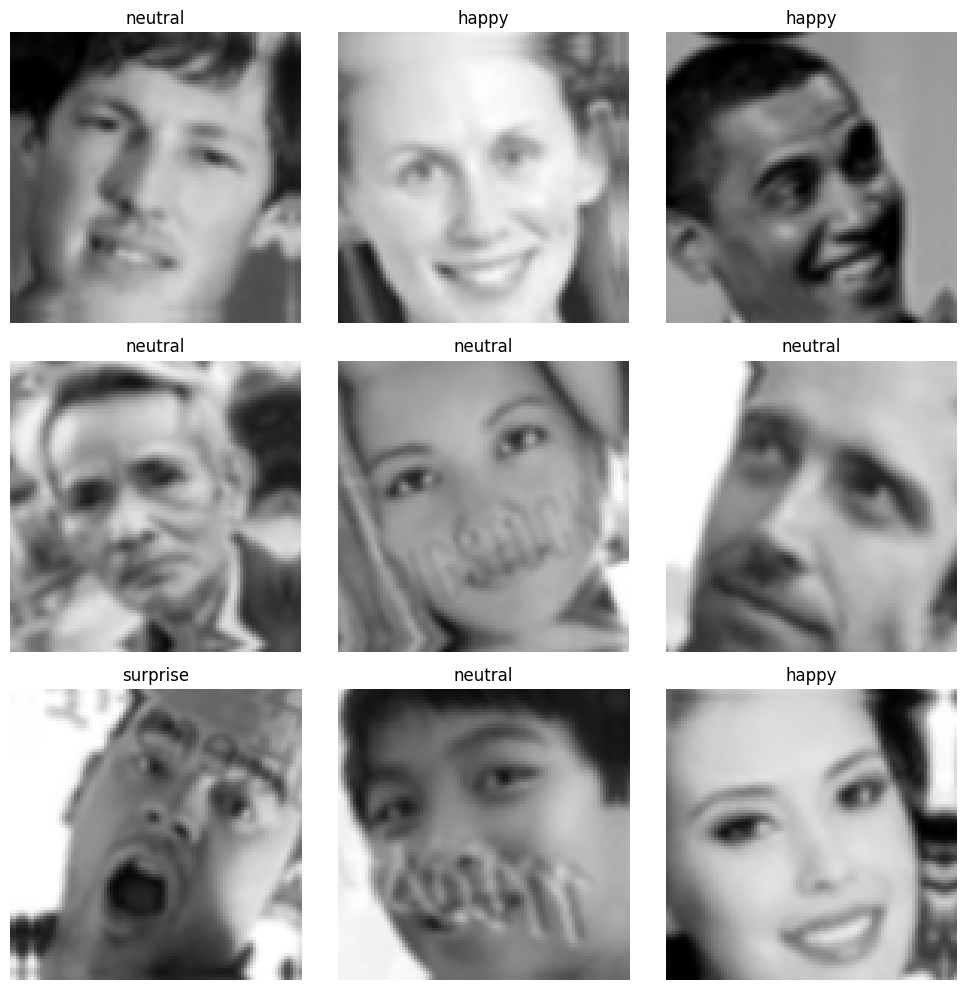

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[np.argmax(labels[i].numpy())])
        plt.axis("off")
plt.tight_layout()
plt.show()

## Aputoiminnot koulutukseen ja arviointiin

In [6]:
def compile_model(model, learning_rate):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def fit_model(model, model_name, learning_rate, epochs):
    model = compile_model(model, learning_rate)
    model_path = MODELS_DIR / f"{model_name}_best.keras"
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(str(model_path), monitor="val_loss", save_best_only=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
    ]
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
    )
    return model, history, model_path


def plot_history(history, title_prefix):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(model, split_name="test"):
    dataset = test_ds if split_name == "test" else val_ds
    probabilities = model.predict(dataset)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in dataset], axis=0)

    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion matrix ({split_name})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return report


## 1. Baseline-CNN

In [7]:
baseline_model = build_model(
    mode="cnn",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=len(class_names),
)
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,215 (1.61 MB)

 Trainable params: 422,215 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 79s 101ms/step - accuracy: 0.2477 - loss: 1.8112 - val_accuracy: 0.2591 - val_loss: 1.7927 - learning_rate: 0.0010
Epoch 2/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 77s 101ms/step - accuracy: 0.2540 - loss: 1.7936 - val_accuracy: 0.2538 - val_loss: 1.8034 - learning_rate: 0.0010
Epoch 3/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 102ms/step - accuracy: 0.2535 - loss: 1.7862 - val_accuracy: 0.2624 - val_loss: 1.7790 - learning_rate: 0.0010
Epoch 4/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 79s 103ms/step - accuracy: 0.2676 - loss: 1.7630 - val_accuracy: 0.2968 - val_loss: 1.7147 - learning_rate: 0.0010
Epoch 5/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 76s 99ms/step - accuracy: 0.3026 - loss: 1.7008 - val_accuracy: 0.3393 - val_loss: 1.6324 - learning_rate: 0.0010
Epoch 6/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 79s 103ms/step - accuracy: 0.3282 - loss: 1.6486 - val_accuracy: 0.3556 - val_loss: 1.5727 - learning_rate: 0.0010
Epoch 7/20
763/763 ━━━━━━━━━━━━━━━━━━━━ 80s 105ms/step - accuracy: 0.36

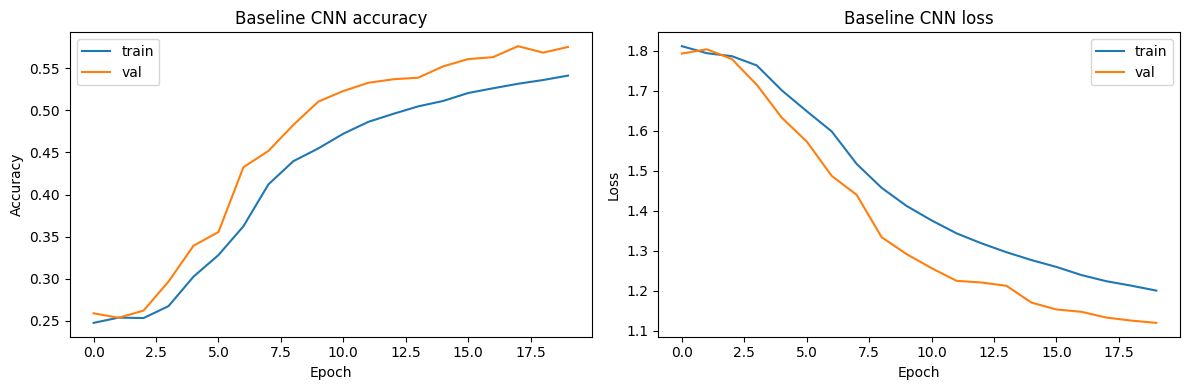

In [8]:
baseline_model, baseline_history, baseline_model_path = fit_model(
    baseline_model,
    model_name="cnn",
    learning_rate=1e-3,
    epochs=20,
)
plot_history(baseline_history, "Baseline CNN")

In [9]:
baseline_test_results = baseline_model.evaluate(test_ds, verbose=1)
print("Baseline test loss:", baseline_test_results[0])
print("Baseline test accuracy:", baseline_test_results[1])

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5659 - loss: 1.1312
Baseline test loss: 1.1312119960784912
Baseline test accuracy: 0.5658957958221436


225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step
              precision    recall  f1-score   support

       angry       0.40      0.59      0.48       958
     disgust       0.00      0.00      0.00       111
        fear       0.37      0.13      0.19      1024
       happy       0.81      0.81      0.81      1774
     neutral       0.52      0.59      0.55      1233
         sad       0.45      0.43      0.44      1247
    surprise       0.65      0.79      0.71       831

    accuracy                           0.57      7178
   macro avg       0.46      0.48      0.45      7178
weighted avg       0.55      0.57      0.54      7178



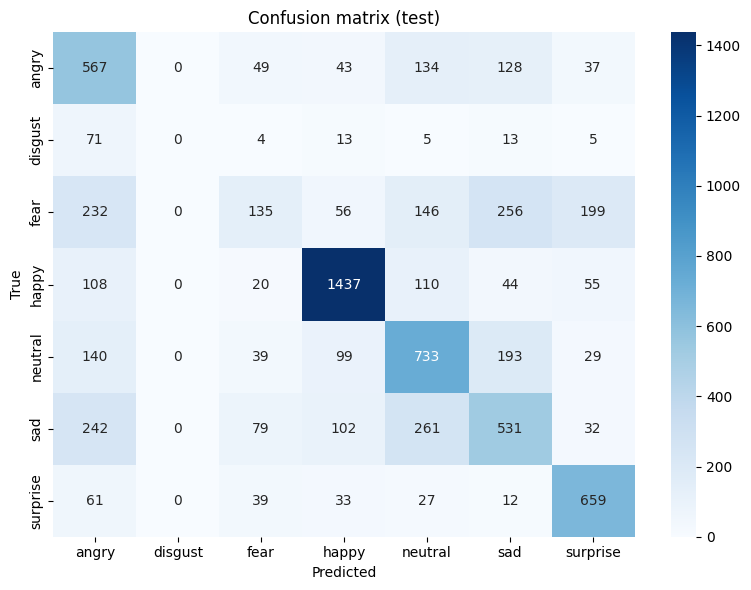

In [10]:
baseline_report = evaluate_model(baseline_model, split_name="test")

## 2. MobileNetV2 feature extraction

In [11]:
feature_model = build_model(
    mode="feature",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    num_classes=len(class_names),
)
feature_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_feature"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,266,951 (8.65 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 68s 84ms/step - accuracy: 0.3424 - loss: 1.7952 - val_accuracy: 0.4290 - val_loss: 1.5176 - learning_rate: 0.0010
Epoch 2/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 61s 80ms/step - accuracy: 0.3941 - loss: 1.5911 - val_accuracy: 0.4253 - val_loss: 1.5242 - learning_rate: 0.0010
Epoch 3/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - accuracy: 0.4050 - loss: 1.5638 - val_accuracy: 0.4385 - val_loss: 1.4886 - learning_rate: 0.0010
Epoch 4/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 61s 80ms/step - accuracy: 0.4048 - loss: 1.5718 - val_accuracy: 0.4271 - val_loss: 1.5066 - learning_rate: 0.0010
Epoch 5/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 61s 80ms/step - accuracy: 0.4117 - loss: 1.5570 - val_accuracy: 0.4237 - val_loss: 1.4956 - learning_rate: 0.0010
Epoch 6/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - accuracy: 0.4240 - loss: 1.5114 - val_accuracy: 0.4439 - val_loss: 1.4611 - learning_rate: 5.0000e-04
Epoch 7/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - accuracy: 0.4231

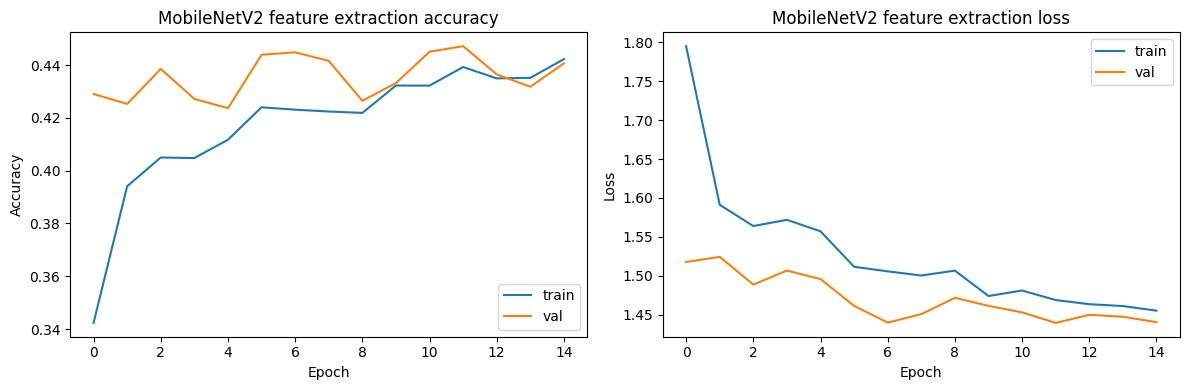

In [12]:
feature_model, feature_history, feature_model_path = fit_model(
    feature_model,
    model_name="feature",
    learning_rate=1e-3,
    epochs=15,
)
plot_history(feature_history, "MobileNetV2 feature extraction")

In [13]:
feature_test_results = feature_model.evaluate(test_ds, verbose=1)
print("Feature model test loss:", feature_test_results[0])
print("Feature model test accuracy:", feature_test_results[1])

225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.4451 - loss: 1.4349
Feature model test loss: 1.434917688369751
Feature model test accuracy: 0.4451100528240204


225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step
              precision    recall  f1-score   support

       angry       0.34      0.29      0.32       958
     disgust       0.50      0.03      0.05       111
        fear       0.36      0.16      0.22      1024
       happy       0.47      0.79      0.59      1774
     neutral       0.41      0.38      0.40      1233
         sad       0.41      0.27      0.33      1247
    surprise       0.57      0.65      0.60       831

    accuracy                           0.45      7178
   macro avg       0.44      0.37      0.36      7178
weighted avg       0.43      0.45      0.41      7178



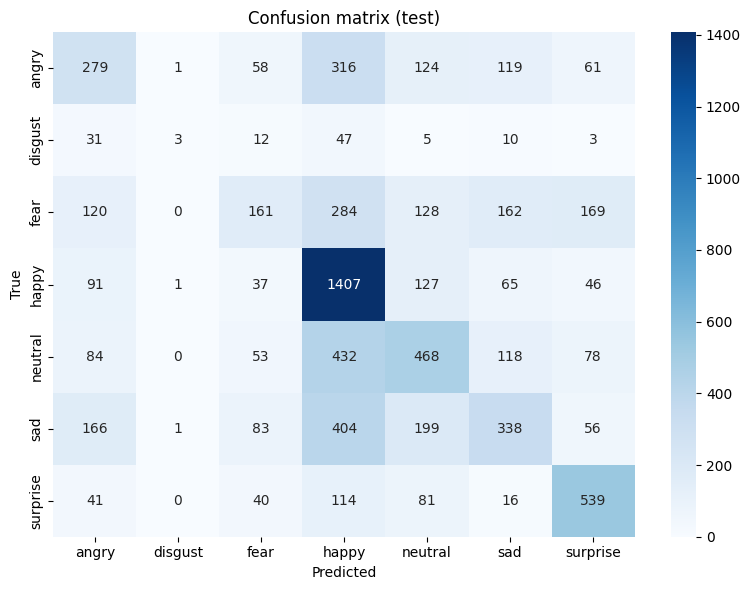

In [14]:
feature_report = evaluate_model(feature_model, split_name="test")

## 3. Fine-tuning (valinnainen)

Tämä vaihe on raskaampi. Aja se vain, jos haluat kolmannen vertailumallin tai paremman tuloksen siirto-oppimisen päälle.

In [18]:
RUN_FINETUNING = True

Epoch 1/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 97ms/step - accuracy: 0.3885 - loss: 1.5675 - val_accuracy: 0.4857 - val_loss: 1.3705 - learning_rate: 1.0000e-04
Epoch 2/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 71s 93ms/step - accuracy: 0.4674 - loss: 1.3985 - val_accuracy: 0.5108 - val_loss: 1.3093 - learning_rate: 1.0000e-04
Epoch 3/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 76s 99ms/step - accuracy: 0.4946 - loss: 1.3330 - val_accuracy: 0.5210 - val_loss: 1.2762 - learning_rate: 1.0000e-04
Epoch 4/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 78s 102ms/step - accuracy: 0.5093 - loss: 1.2909 - val_accuracy: 0.5322 - val_loss: 1.2528 - learning_rate: 1.0000e-04
Epoch 5/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 75s 97ms/step - accuracy: 0.5241 - loss: 1.2485 - val_accuracy: 0.5392 - val_loss: 1.2309 - learning_rate: 1.0000e-04
Epoch 6/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 77s 100ms/step - accuracy: 0.5318 - loss: 1.2253 - val_accuracy: 0.5389 - val_loss: 1.2060 - learning_rate: 1.0000e-04
Epoch 7/15
763/763 ━━━━━━━━━━━━━━━━━━━━ 73s 95ms/s

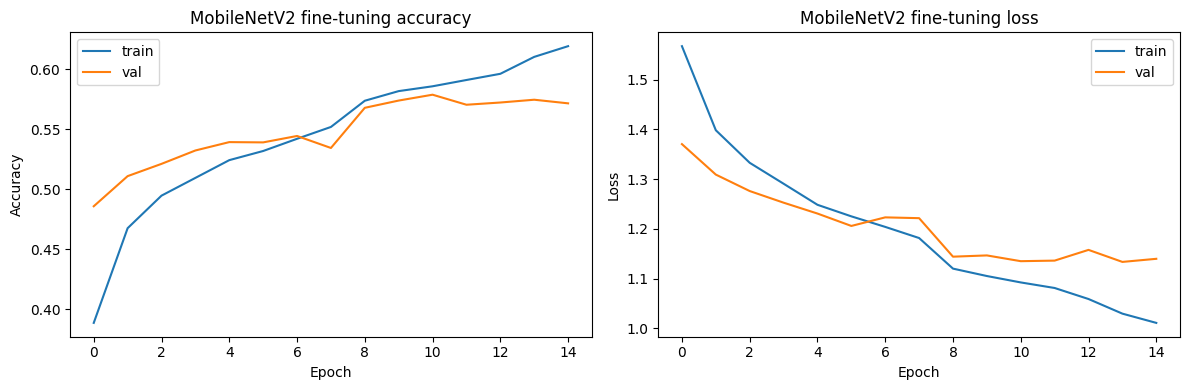

225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.5663 - loss: 1.1575
Fine-tuned model test loss: 1.1574724912643433
Fine-tuned model test accuracy: 0.5663137435913086
225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step
              precision    recall  f1-score   support

       angry       0.42      0.53      0.47       958
     disgust       0.59      0.17      0.27       111
        fear       0.47      0.28      0.35      1024
       happy       0.75      0.81      0.78      1774
     neutral       0.52      0.52      0.52      1233
         sad       0.46      0.42      0.44      1247
    surprise       0.63      0.78      0.69       831

    accuracy                           0.57      7178
   macro avg       0.55      0.50      0.50      7178
weighted avg       0.56      0.57      0.56      7178



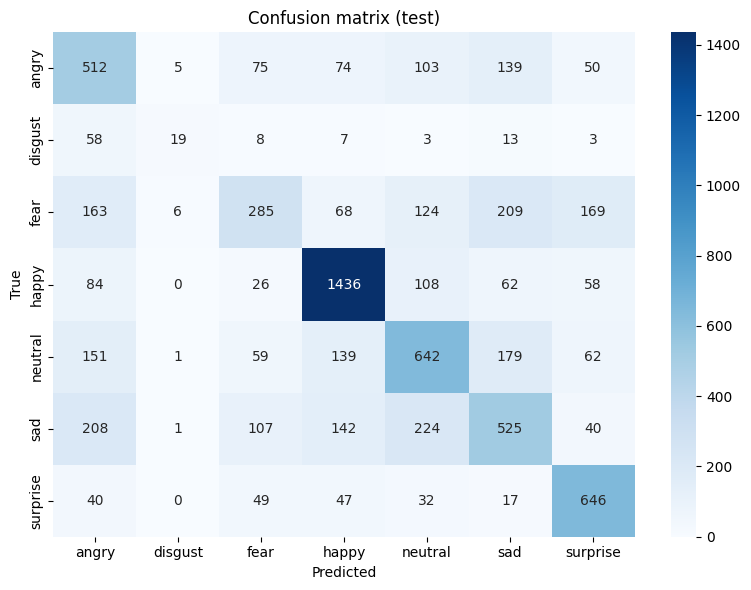

In [19]:
if RUN_FINETUNING:
    finetune_model = build_model(
        mode="finetune",
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        num_classes=len(class_names),
        unfrozen_layers=20,
    )
    finetune_model, finetune_history, finetune_model_path = fit_model(
        finetune_model,
        model_name="finetune",
        learning_rate=1e-4,
        epochs=15,
    )
    plot_history(finetune_history, "MobileNetV2 fine-tuning")
    finetune_test_results = finetune_model.evaluate(test_ds, verbose=1)
    print("Fine-tuned model test loss:", finetune_test_results[0])
    print("Fine-tuned model test accuracy:", finetune_test_results[1])
    finetune_report = evaluate_model(finetune_model, split_name="test")

## Tulosten tallennus yhteenvetoon

In [17]:
summary = {
    "class_names": class_names,
    "baseline_test_accuracy": float(baseline_test_results[1]),
    "feature_test_accuracy": float(feature_test_results[1]),
}

if RUN_FINETUNING and "finetune_test_results" in globals():
    summary["finetune_test_accuracy"] = float(finetune_test_results[1])

summary_path = REPORT_DIR / "notebook_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

summary

{'class_names': ['angry',
  'disgust',
  'fear',
  'happy',
  'neutral',
  'sad',
  'surprise'],
 'baseline_test_accuracy': 0.5658957958221436,
 'feature_test_accuracy': 0.4451100528240204}

## Pohdinta

Projektin tulokset osoittivat, että tunnetilan tunnistus FER-2013-datasetillä on selvästi haastava tehtävä. Paras testitarkkuus saavutettiin MobileNetV2:n fine-tuned versiolla (`0.5663`), mutta myös baseline-CNN pääsi lähes samaan tulokseen (`0.5659`). Sen sijaan pelkkä MobileNetV2 feature extraction jäi selvästi heikommaksi (`0.4451`). Tämä viittaa siihen, että esikoulutettu runko ei yksin riittänyt tähän tehtävään, vaan mallin piirteitä piti hienosäätää tunnetilaluokitteluun sopivammiksi.

Luokkakohtaiset tulokset olivat myös opettavaisia. `happy` ja `surprise` tunnistuivat parhaiten, mikä on loogista, koska ne ovat usein visuaalisesti selkeämpiä kuin monet muut tunnetilat. Vaikeimpia luokkia olivat `disgust` ja `fear`. Erityisesti `disgust` kärsi sekä datan pienestä määrästä että siitä, että ilme muistuttaa helposti muita negatiivisia tunnetiloja. Fine-tuning paransi vaikeita luokkia enemmän kuin pelkkä feature extraction, mikä tekee siitä tärkeän osan projektin johtopäätöksiä.

Projektin kannalta kiinnostavaa oli myös se, että yksinkertainen baseline-CNN oli yllättävän kilpailukykyinen. Tämä muistuttaa siitä, että siirto-oppiminen ei automaattisesti voita yksinkertaisempaa mallia, varsinkaan jos esikoulutettua verkkoa ei mukauteta tarpeeksi tehtävän erityispiirteisiin. Samalla tulokset osoittavat, että tunnetilaluokittelu ei ole vain tekninen ongelma vaan myös eettinen: kasvojen ilme ei aina vastaa henkilön todellista tunnetta, ja mallien käyttö käytännön sovelluksissa vaatii erityistä varovaisuutta.